# 03 · Preprocessing & modality merge

| | |
|---|---|
| **入力** | `data/formatted/<subject>/<session>.csv` |
| **出力** | `data/clean/<subject>.csv`（被験者ごとに 1 ファイル） |

処理内容:
1. **EEG** — 2 kHz → 1 kHz にリサンプルし, 非脳成分を ICA（ICLabel）で除去する.
   安静な立位／座位区間でフィットする. バースト状アーティファクト除去（ASR）は
   現在, 手元の numpy と `asrpy` の組み合わせで内部エラーになるため無効化中
   （`clean_eeg(..., use_asr=False)`）.
2. **EMG** — 日本語筋名のヘッダを短いローマ字 ID にリネームする.
3. **モーション** — 30 Hz で低域通過し, X/Z 地面平面軸を `*_XZ` に統合,    0.1 s / 0.2 s 遅延コピーを追加する.
4. 3 モダリティを `t_sec` で連結し, `label` 列を保持したまま, 被験者の全    セッションを `Session` ID 付きで縦積みする.

このノートブックはオフライン処理だが, 実運用（リアルタイム推定）を想定しているため,
欠損値の穴埋めは前後の値を使う補間ではなく, 直近の値を保持する前方補外
（zero-order hold, `ffill`）にしてある。線形補間は「まだ来ていない未来のサンプル」を
使ってしまい, リアルタイム環境では再現できない。

In [1]:
import sys
from pathlib import Path

# notebooks/ から実行したときに motion_intent パッケージを import 可能にする
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from motion_intent import config

In [2]:
from motion_intent.preprocessing import (
    estimate_fs_from_time, decimate_to, clean_eeg,
    lowpass, merge_xz_all, drop_single_axis_marker_cols,
    extract_static_segments,
)

## Load a subject's sessions

In [3]:
subject = 'haru'      # ← 自分の被験者フォルダ名に変更
session_paths = sorted((config.FORMATTED_DIR / subject).glob('*.csv'))
assert session_paths, (
    f'no labelled sessions under {config.FORMATTED_DIR / subject} - '
    f'run notebook 02 first, or fix the subject name'
)
print(f'{len(session_paths)} sessions for {subject}')

10 sessions for haru


## EEG: resample + artefact cleaning

In [4]:
def preprocess_eeg(df):
    fs_in = estimate_fs_from_time(df['t_sec'])
    q = max(1, round(fs_in / config.FS))

    # decimate_to only returns EEG_CH_ALL + t_sec; carry every other column
    # (EMG_*, Markers_*, RigidBodies_*, label) along at the same stride so
    # preprocess_emg/preprocess_motion still have something to work on.
    other_cols = [c for c in df.columns if c not in config.EEG_CH_ALL and c != 't_sec']
    passthrough = df[other_cols].iloc[::q].reset_index(drop=True)

    df = decimate_to(df, config.EEG_CH_ALL, q=q)
    df = pd.concat([df, passthrough.iloc[:len(df)]], axis=1)

    calib = extract_static_segments(df, label_col='label', fs=config.FS)
    # ASR disabled for now: the installed asrpy raises a TypeError inside
    # asr_utils.fit_eeg_distribution against this numpy version (see
    # preprocessing.clean_eeg docstring). ICA/ICLabel cleaning still runs.
    df = clean_eeg(df, config.EEG_CH_ALL, fs=config.FS, df_calib=calib, use_asr=False)
    return df

## EMG: rename headers

`EMG_Stream`'s channels are generic (`EMG0`..`EMG7`), not muscle names - the mapping to a
physical sensor comes from the matching raw device CSV and differs by session
(`config.emg_rename_for`, see its docstring for the one known rewiring).

In [5]:
import re


def session_id(path):
    """`ses-1431f` -> `'1431f'` (full id incl. speed, unlike notebook 02's
    session_number - the EMG rewiring split is within a session number)."""
    return re.search(r"ses-(\d+[a-z]*)_", path.name).group(1)


def preprocess_emg(df, path):
    return df.rename(columns=config.emg_rename_for(session_id(path)))

## Motion: low-pass, axis merge, lag features

In [6]:
def preprocess_motion(df):
    raw_marker_cols = [c for c in df.columns if c.startswith('Markers_')]
    fs_m = estimate_fs_from_time(df['t_sec'])

    # Markers_* are >95% NaN between mocap samples (much slower than EEG/EMG in
    # the merged frame) - filtfilt/lfilter propagate a single NaN through their
    # whole output, so gaps must be filled before lowpass, not after. Forward-fill
    # (zero-order-hold) rather than interpolate: this pipeline stands in for a
    # real-time system, which only ever has the *last* marker sample, never the
    # next one. Only the leading gap (before the first real sample) falls back
    # to the first available value.
    df = df.copy()
    df[raw_marker_cols] = df[raw_marker_cols].ffill().bfill()

    df = lowpass(df, raw_marker_cols, fs=fs_m, cutoff_hz=30.0, zero_phase=False)
    df = drop_single_axis_marker_cols(merge_xz_all(df))

    for lag_s in (0.1, 0.2):
        shift = int(lag_s * config.FS)
        for c in config.MOTION_COLS:
            df[f'{c}_t-{lag_s}s'] = df[c].shift(shift)
    return df

## Merge modalities and stack sessions

In [7]:
frames = []
for i, path in enumerate(session_paths):
    df = pd.read_csv(path)
    df = preprocess_eeg(df)
    df = preprocess_emg(df, path)
    df = preprocess_motion(df)
    df['Session'] = i
    frames.append(df)

clean = pd.concat(frames, ignore_index=True)
out_path = config.CLEAN_DIR / f'{subject}.csv'
out_path.parent.mkdir(parents=True, exist_ok=True)
clean.to_csv(out_path, index=False)
print(out_path, clean.shape)

Creating RawArray with float64 data, n_channels=32, n_times=27990
    Range : 0 ... 27989 =      0.000 ...    27.989 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, non-linear phase, causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 1.00 Hz
- Upper transition bandwidth: 10.00 Hz
- Filter length: 3301 samples (3.301 s)

Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by number: 30 components
Fitting ICA took 2.0s.


c:\Users\rikky\research\2025\eeg-emg-motion-intention\src\motion_intent\preprocessing.py:253: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw_fit, ica, method="iclabel")["labels"]
c:\Users\rikky\research\2025\eeg-emg-motion-intention\src\motion_intent\preprocessing.py:253: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw_fit, ica, method="iclabel")["labels"]
c:\Users\rikky\research\2025\eeg-emg-motion-intention\src\motion_intent\preprocessing.py:253: RuntimeWarning: The provided ICA instance was fitted with 

Creating RawArray with float64 data, n_channels=32, n_times=51276
    Range : 0 ... 51275 =      0.000 ...    51.275 secs
Ready.
Applying ICA to Raw instance
    Transforming to ICA space (30 components)
    Zeroing out 22 ICA components
    Projecting back using 32 PCA components
Creating RawArray with float64 data, n_channels=32, n_times=38745
    Range : 0 ... 38744 =      0.000 ...    38.744 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, non-linear phase, causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 1.00 Hz
- Upper transition bandwidth: 10.00 Hz
- Filter length: 3301 samples (3.301 s)

Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by number: 30 components
Fitting ICA took 2.6s.


c:\Users\rikky\research\2025\eeg-emg-motion-intention\src\motion_intent\preprocessing.py:253: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw_fit, ica, method="iclabel")["labels"]
c:\Users\rikky\research\2025\eeg-emg-motion-intention\src\motion_intent\preprocessing.py:253: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw_fit, ica, method="iclabel")["labels"]
c:\Users\rikky\research\2025\eeg-emg-motion-intention\src\motion_intent\preprocessing.py:253: RuntimeWarning: The provided ICA instance was fitted with 

Creating RawArray with float64 data, n_channels=32, n_times=62952
    Range : 0 ... 62951 =      0.000 ...    62.951 secs
Ready.
Applying ICA to Raw instance
    Transforming to ICA space (30 components)
    Zeroing out 19 ICA components
    Projecting back using 32 PCA components
Creating RawArray with float64 data, n_channels=32, n_times=50191
    Range : 0 ... 50190 =      0.000 ...    50.190 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, non-linear phase, causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 1.00 Hz
- Upper transition bandwidth: 10.00 Hz
- Filter length: 3301 samples (3.301 s)

Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by number: 30 components
Fitting ICA took 1.2s.


...

Creating RawArray with float64 data, n_channels=32, n_times=47201
    Range : 0 ... 47200 =      0.000 ...    47.200 secs
Ready.
Applying ICA to Raw instance
    Transforming to ICA space (30 components)
    Zeroing out 20 ICA components
    Projecting back using 32 PCA components
Creating RawArray with float64 data, n_channels=32, n_times=34351
    Range : 0 ... 34350 =      0.000 ...    34.350 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, non-linear phase, causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 1.00 Hz
- Upper transition bandwidth: 10.00 Hz
- Filter length: 3301 samples (3.301 s)

Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by number: 30 components
Fitting ICA took 1.8s.


c:\Users\rikky\research\2025\eeg-emg-motion-intention\src\motion_intent\preprocessing.py:253: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw_fit, ica, method="iclabel")["labels"]
c:\Users\rikky\research\2025\eeg-emg-motion-intention\src\motion_intent\preprocessing.py:253: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw_fit, ica, method="iclabel")["labels"]
c:\Users\rikky\research\2025\eeg-emg-motion-intention\src\motion_intent\preprocessing.py:253: RuntimeWarning: The provided ICA instance was fitted with 

Creating RawArray with float64 data, n_channels=32, n_times=59436
    Range : 0 ... 59435 =      0.000 ...    59.435 secs
Ready.
Applying ICA to Raw instance
    Transforming to ICA space (30 components)
    Zeroing out 22 ICA components
    Projecting back using 32 PCA components
Creating RawArray with float64 data, n_channels=32, n_times=40363
    Range : 0 ... 40362 =      0.000 ...    40.362 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, non-linear phase, causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 1.00 Hz
- Upper transition bandwidth: 10.00 Hz
- Filter length: 3301 samples (3.301 s)

Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by number: 30 components
Fitting ICA took 1.1s.


c:\Users\rikky\research\2025\eeg-emg-motion-intention\src\motion_intent\preprocessing.py:253: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw_fit, ica, method="iclabel")["labels"]
c:\Users\rikky\research\2025\eeg-emg-motion-intention\src\motion_intent\preprocessing.py:253: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw_fit, ica, method="iclabel")["labels"]
c:\Users\rikky\research\2025\eeg-emg-motion-intention\src\motion_intent\preprocessing.py:253: RuntimeWarning: The provided ICA instance was fitted with 

Creating RawArray with float64 data, n_channels=32, n_times=74085
    Range : 0 ... 74084 =      0.000 ...    74.084 secs
Ready.
Applying ICA to Raw instance
    Transforming to ICA space (30 components)
    Zeroing out 24 ICA components
    Projecting back using 32 PCA components
C:\Users\rikky\research\2025\eeg-emg-motion-intention\data\clean\haru.csv (827920, 111)


## Visualise one session's preprocessed output

Sanity check before moving on to feature extraction: EEG (post ICA-clean), EMG, and one
motion marker (with its two lag copies) for a single session, with the `label` track
shaded behind each panel so a mislabelled or misaligned stretch is easy to spot by eye.

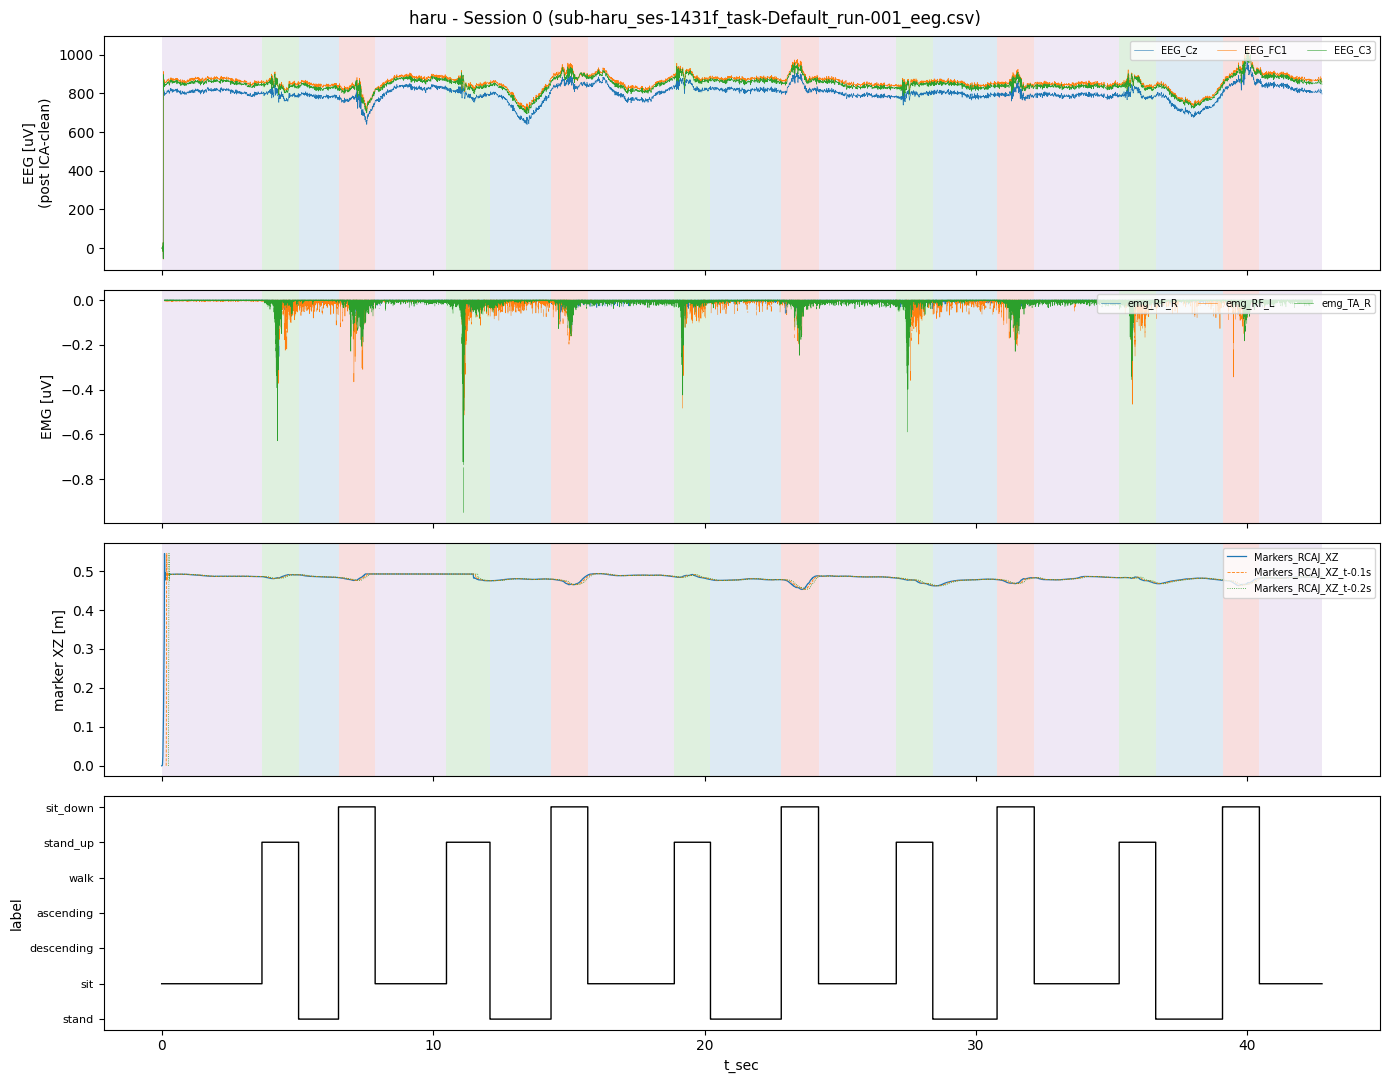

In [8]:
LABEL_COLORS = {
    'stand': 'tab:blue', 'sit': 'tab:purple', 'walk': 'tab:orange',
    'ascending': 'tab:green', 'stand_up': 'tab:green',
    'descending': 'tab:red', 'sit_down': 'tab:red',
}


def shade_labels(ax, t, labels):
    change = np.where(labels[1:] != labels[:-1])[0] + 1
    starts = np.concatenate(([0], change))
    ends = np.concatenate((change, [len(labels)]))
    for s, e in zip(starts, ends):
        ax.axvspan(t[s], t[min(e, len(t) - 1)], color=LABEL_COLORS.get(labels[s], 'gray'), alpha=0.15, lw=0)


session_to_plot = 0      # ← Session 列の番号(session_paths のインデックス)を変更して見比べる
seg = clean[clean['Session'] == session_to_plot].reset_index(drop=True)
t = seg['t_sec'].to_numpy()
labels = seg['label'].to_numpy()

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

for ch in config.EEG_CH_FEATURE[:3]:
    axes[0].plot(t, seg[ch], lw=0.4, label=ch)
axes[0].set_ylabel('EEG [uV]\n(post ICA-clean)'); axes[0].legend(fontsize=7, ncol=3, loc='upper right')
shade_labels(axes[0], t, labels)

for ch in config.EMG_COLS[:3]:
    axes[1].plot(t, seg[ch], lw=0.4, label=ch)
axes[1].set_ylabel('EMG [uV]'); axes[1].legend(fontsize=7, ncol=3, loc='upper right')
shade_labels(axes[1], t, labels)

m = config.MOTION_COLS[0]
axes[2].plot(t, seg[m], lw=0.9, label=m)
axes[2].plot(t, seg[f'{m}_t-0.1s'], lw=0.6, ls='--', label=f'{m}_t-0.1s')
axes[2].plot(t, seg[f'{m}_t-0.2s'], lw=0.6, ls=':', label=f'{m}_t-0.2s')
axes[2].set_ylabel('marker XZ [m]'); axes[2].legend(fontsize=7, loc='upper right')
shade_labels(axes[2], t, labels)

class_ids = [config.CLASS_NAMES.index(l) for l in labels]
axes[3].plot(t, class_ids, drawstyle='steps-post', color='black', lw=1)
axes[3].set_yticks(range(len(config.CLASS_NAMES)))
axes[3].set_yticklabels(config.CLASS_NAMES, fontsize=8)
axes[3].set_ylabel('label'); axes[3].set_xlabel('t_sec')

fig.suptitle(f'{subject} - Session {session_to_plot} ({session_paths[session_to_plot].name})')
plt.tight_layout()